In [ ]:
# ============================================================
# CELL 1: Install Dependencies
# Run once per session (fast, ~30s)
# ============================================================

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

packages = [
    "huggingface_hub",
    "requests",
    "python-dotenv",
    "pandas",
    "numpy",
    "snowflake-connector-python",
    "snowflake-connector-python[pandas]",
    "kaggle",
    "qdrant-client",
    "sentence-transformers",
    "transformers",
    "accelerate",
    "pillow",
    "qwen-vl-utils",
    "tqdm",
]

for pkg in packages:
    try:
        install(pkg)
    except Exception as e:
        print(f"WARNING: Failed to install {pkg}: {e}")

print("All dependencies installed")

All dependencies installed


In [ ]:
# ============================================================
# CELL 2: Configure API Keys (Kaggle + HuggingFace)
# ONE-TIME per session — keys stored in Colab Secrets.
# If you've already set secrets in the Colab UI sidebar,
# this cell just validates them.
# ============================================================

import os
from google.colab import userdata

# ── Kaggle ──────────────────────────────────────────────────
kaggle_dir = os.path.expanduser("~/.kaggle")
kaggle_json = os.path.join(kaggle_dir, "kaggle.json")

if not os.path.isfile(kaggle_json):
    # Try to build kaggle.json from Colab secrets
    try:
        kaggle_username = userdata.get("KAGGLE_USERNAME")
        kaggle_key      = userdata.get("KAGGLE_KEY")
        os.makedirs(kaggle_dir, exist_ok=True)
        import json
        with open(kaggle_json, "w") as f:
            json.dump({"username": kaggle_username, "api_key": kaggle_key}, f)
        os.chmod(kaggle_json, 0o600)
        print("kaggle.json created from Colab secrets")
    except Exception:
        # Fall back to manual upload
        print("KAGGLE_USERNAME / KAGGLE_KEY not found in secrets.")
        print("Upload kaggle.json manually:")
        from google.colab import files
        uploaded = files.upload()
        if "kaggle.json" in uploaded:
            os.makedirs(kaggle_dir, exist_ok=True)
            os.rename("kaggle.json", kaggle_json)
            os.chmod(kaggle_json, 0o600)
            print("kaggle.json uploaded manually")
        else:
            raise RuntimeError("kaggle.json not uploaded. Cannot continue.")
else:
    print("kaggle.json already configured")

# ── HuggingFace ─────────────────────────────────────────────
try:
    hf_token = userdata.get("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
    print("HF_TOKEN loaded from secrets")
except Exception:
    print("HF_TOKEN not in secrets — public model downloads only (may be rate-limited)")

KAGGLE_USERNAME / KAGGLE_KEY not found in secrets.
Upload kaggle.json manually:


Saving kaggle.json to kaggle.json
kaggle.json uploaded manually
HF_TOKEN loaded from secrets


In [ ]:
# ============================================================
# CELL 3: Download Datasets
# SKIPS automatically if already downloaded.
# Safe to re-run — no duplicate downloads.
# ============================================================

import os
from huggingface_hub import snapshot_download

JEWELRY_DIR  = "/content/jewelry_hf"
CARS_DIR     = "/content/cars"
PROPERTY_DIR = "/content/property"

# ── Jewelry (HuggingFace) ────────────────────────────────────
jewelry_zip = os.path.join(JEWELRY_DIR, "dataset.zip")
if os.path.isfile(jewelry_zip):
    print("Jewelry dataset already downloaded — skipping")
else:
    print("Downloading jewelry dataset...")
    try:
        snapshot_download(
            repo_id="sidd707/jewelry-design-dataset",
            repo_type="dataset",
            local_dir=JEWELRY_DIR,
        )
        print("Jewelry dataset downloaded")
    except Exception as e:
        raise RuntimeError(f"Jewelry download failed: {e}")

# ── Cars (Kaggle) ────────────────────────────────────────────
cars_csv = "/content/cars/train/train/train.csv"
if os.path.isfile(cars_csv):
    print("Cars dataset already downloaded — skipping")
else:
    print("Downloading cars dataset...")
    try:
        os.makedirs(CARS_DIR, exist_ok=True)
        os.system(f"kaggle datasets download -d sudhanshu2198/ripik-hackfest --unzip -p {CARS_DIR}")
        print("Cars dataset downloaded")
    except Exception as e:
        raise RuntimeError(f"Cars download failed: {e}")

# ── Property (Kaggle) ────────────────────────────────────────
property_dir_check = "/content/property/kaggle_room_street_data"
if os.path.isdir(property_dir_check):
    print("Property dataset already downloaded — skipping")
else:
    print("Downloading property dataset...")
    try:
        os.makedirs(PROPERTY_DIR, exist_ok=True)
        os.system(f"kaggle datasets download -d mikhailma/house-rooms-streets-image-dataset --unzip -p {PROPERTY_DIR}")
        print("Property dataset downloaded")
    except Exception as e:
        raise RuntimeError(f"Property download failed: {e}")

print("\nAll datasets ready")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Jewelry dataset downloaded
Cars dataset downloaded
Property dataset downloaded

All datasets ready


In [ ]:
# ============================================================
# CELL 4: Extract Jewelry ZIP
# SKIPS if already extracted.
# ============================================================

import zipfile, os

zip_path     = "/content/jewelry_hf/dataset.zip"
extract_path = "/content/jewelry_hf/extracted"
marker       = os.path.join(extract_path, "dataset", "dataset_labels.csv")

if os.path.isfile(marker):
    print("Jewelry ZIP already extracted — skipping")
else:
    print("Extracting jewelry ZIP...")
    try:
        os.makedirs(extract_path, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_path)
        print("Jewelry ZIP extracted")
        for item in os.listdir(extract_path):
            full = os.path.join(extract_path, item)
            print(f"  {item}:", os.listdir(full)[:5] if os.path.isdir(full) else "")
    except Exception as e:
        raise RuntimeError(f"Extraction failed: {e}")

Extracting jewelry ZIP...
Jewelry ZIP extracted
  dataset: ['dataset_labels.csv', 'earring_best', 'bracelet', 'necklace', 'ring_best']


In [ ]:
# ============================================================
# CELL 5: Shared Utilities
# Always run — defines helper functions used by later cells.
# ============================================================

import os, uuid, json
import pandas as pd

def get_value_tier(price_str):
    """Map a price string to high / medium / low / unknown."""
    if price_str is None:
        return "unknown"
    try:
        price = float(str(price_str).replace("$", "").replace(",", "").strip())
        if price >= 5000:  return "high"
        elif price >= 500: return "medium"
        else:              return "low"
    except (ValueError, TypeError):
        return "unknown"

SCHEMA_COLS = [
    "record_id", "image_id", "image_path", "object_type", "object_name",
    "condition", "estimated_value_tier", "location_context",
    "source_dataset", "source_flag",
]

print("Shared utilities loaded")

Shared utilities loaded


In [ ]:
# ============================================================
# CELL 6: Build Jewelry Ground Truth Records
# ============================================================

import pandas as pd, os, uuid

BASE_PATH = "/content/jewelry_hf/extracted/dataset"

JEWELRY_VALUE_MAP = {
    "ring_best":    "high",
    "bracelet":     "medium",
    "necklace":     "high",
    "earring_best": "medium",
}

try:
    labels = pd.read_csv(os.path.join(BASE_PATH, "dataset_labels.csv"), encoding="latin-1")
except FileNotFoundError:
    raise RuntimeError("dataset_labels.csv not found. Did Cell 4 run successfully?")

jewelry_records = []
skipped_bad_path = skipped_missing = 0

for _, row in labels.iterrows():
    try:
        raw_path = str(row["image_path"]).replace("\\", "/").replace("$", "/")
        while "//" in raw_path:
            raw_path = raw_path.replace("//", "/")

        parts = [p for p in raw_path.split("/") if p]
        if len(parts) < 2:
            skipped_bad_path += 1
            continue

        category       = parts[0]
        image_file     = parts[-1].lstrip("_")
        if not image_file:
            skipped_bad_path += 1
            continue

        full_path = os.path.join(BASE_PATH, category, image_file)
        if not os.path.isfile(full_path):
            skipped_missing += 1
            continue

        jewelry_records.append({
            "record_id":            str(uuid.uuid4()),
            "image_id":             f"{category}__{image_file}",
            "image_path":           full_path,
            "object_type":          "jewelry",
            "object_name":          str(row["description"])[:100],
            "condition":            "new",
            "estimated_value_tier": JEWELRY_VALUE_MAP.get(category, "medium"),
            "location_context":     "home interior",
            "source_dataset":       "jewelry_hf",
            "source_flag":          "GROUND_TRUTH",
        })
    except Exception as e:
        print(f"  ⚠️  Row error: {e}")
        skipped_bad_path += 1

jewel_clean = pd.DataFrame(jewelry_records)

dupe_count = len(jewel_clean) - jewel_clean["image_id"].nunique()
if dupe_count > 0:
    print(f"{dupe_count} duplicate image_ids detected — deduplicating")
    jewel_clean = jewel_clean.drop_duplicates(subset="image_id", keep="first")

print(f"Jewelry: {len(jewel_clean)} records (skipped bad_path={skipped_bad_path}, missing={skipped_missing})")
print(jewel_clean[["image_id", "object_name"]].head(3))

Jewelry: 6155 records (skipped bad_path=0, missing=1)
                     image_id  \
0  bracelet__00G0FPIT4D9J.jpg   
1  bracelet__01D7PTXV8C7F.jpg   
2  bracelet__02G14031IMEF.jpg   

                                         object_name  
0  A stack of eight bracelets in varying shades o...  
1  A pair of matte black metal cuff bracelets, on...  
2  A gold-toned bangle bracelet encrusted with sm...  


In [ ]:
# ============================================================
# CELL 7: Build Property Ground Truth Records
# ============================================================

import os, uuid
import pandas as pd

PROPERTY_BASE = "/content/property/kaggle_room_street_data"

ROOM_MAP = {
    "bed":     ("bedroom",      "home interior", "medium"),
    "bath":    ("bathroom",     "home interior", "medium"),
    "kitchen": ("kitchen",      "home interior", "medium"),
    "living":  ("living room",  "home interior", "medium"),
    "din":     ("dining room",  "home interior", "medium"),
    "kid":     ("kids room",    "home interior", "low"),
}

STREET_MAP = {
    "retail":       ("retail property",      "outdoor", "high"),
    "industrial":   ("industrial property",  "outdoor", "medium"),
    "apartments":   ("apartment building",   "outdoor", "high"),
    "church":       ("church",               "outdoor", "medium"),
    "portland":     ("residential property", "outdoor", "high"),
    "house":        ("house exterior",       "outdoor", "high"),
    "street":       ("street property",      "outdoor", "medium"),
}

def get_property_meta(filename, folder_type):
    name_lower = filename.lower()
    if folder_type == "house_data":
        for prefix, vals in ROOM_MAP.items():
            if name_lower.startswith(prefix):
                return vals
        return ("home interior", "home interior", "medium")
    elif folder_type == "street_data":
        for prefix, vals in STREET_MAP.items():
            if prefix in name_lower:
                return vals
        return ("property exterior", "outdoor", "medium")
    return ("property", "unknown", "medium")

property_records = []
skipped = 0

for folder_type in ["house_data", "street_data"]:
    folder_path = f"{PROPERTY_BASE}/{folder_type}"
    if not os.path.isdir(folder_path):
        print(f"{folder_type} not found — skipping")
        continue
    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            skipped += 1
            continue
        try:
            obj_name, location, value_tier = get_property_meta(filename, folder_type)
            property_records.append({
                "record_id":            str(uuid.uuid4()),
                "image_id":             filename,
                "image_path":           os.path.join(folder_path, filename),
                "object_type":          "property",
                "object_name":          obj_name,
                "condition":            "good",
                "estimated_value_tier": value_tier,
                "location_context":     location,
                "source_dataset":       "house_rooms_streets",
                "source_flag":          "GROUND_TRUTH",
            })
        except Exception as e:
            print(f"Error processing {filename}: {e}")
            skipped += 1

property_clean = pd.DataFrame(property_records)
print(f"Property: {len(property_clean)} records  (skipped non-images: {skipped})")
print(property_clean["object_name"].value_counts().head(5))

Property: 24907 records  (skipped non-images: 0)
object_name
property exterior      9291
retail property        2465
industrial property    2446
church                 2446
house exterior         2364
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 8: Build Vehicle Ground Truth Records
# ============================================================

import os, uuid
import pandas as pd

CARS_IMAGE_FOLDER = "/content/cars/train/train/images"
CARS_CSV          = "/content/cars/train/train/train.csv"

CAR_LABEL_MAP = {1: "no damage", 2: "minor damage", 3: "moderate damage", 4: "severe damage"}
CAR_CONDITION  = {1: "excellent",  2: "good",         3: "fair",            4: "poor"}

try:
    cars_df = pd.read_csv(CARS_CSV)
except FileNotFoundError:
    raise RuntimeError(f"Cars CSV not found at {CARS_CSV}. Did Cell 3 run?")

car_records = []
for _, row in cars_df.iterrows():
    try:
        label_num = int(row.get("label", 1))
        filename  = str(row.get("filename", ""))
        car_records.append({
            "record_id":            str(uuid.uuid4()),
            "image_id":             filename,
            "image_path":           os.path.join(CARS_IMAGE_FOLDER, filename),
            "object_type":          "vehicle",
            "object_name":          CAR_LABEL_MAP.get(label_num, "vehicle"),
            "condition":            CAR_CONDITION.get(label_num, "unknown"),
            "estimated_value_tier": "medium",
            "location_context":     "outdoor",
            "source_dataset":       "ripik_cars",
            "source_flag":          "GROUND_TRUTH",
        })
    except Exception as e:
        print(f"Row error: {e}")

cars_clean = pd.DataFrame(car_records)
print(f"Vehicles: {len(cars_clean)} records")
print(cars_clean["condition"].value_counts())

Vehicles: 7200 records
condition
good         2349
poor         2079
unknown      2067
fair          534
excellent     171
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 9: Combine All Ground Truth Into One DataFrame
# ============================================================

import pandas as pd

ground_truth = pd.concat(
    [jewel_clean, property_clean, cars_clean],
    ignore_index=True
)[SCHEMA_COLS]

print(f"Total ground truth records: {len(ground_truth)}")
print("\nBy source dataset:")
print(ground_truth["source_dataset"].value_counts())
print("\nBy object type:")
print(ground_truth["object_type"].value_counts())

# Sanity check
assert len(ground_truth) > 0, "ground_truth is empty!"
assert set(SCHEMA_COLS).issubset(ground_truth.columns), "Missing required columns!"
print("\nSchema validated")

Total ground truth records: 38262

By source dataset:
source_dataset
house_rooms_streets    24907
ripik_cars              7200
jewelry_hf              6155
Name: count, dtype: int64

By object type:
object_type
property    24907
vehicle      7200
jewelry      6155
Name: count, dtype: int64

Schema validated


In [ ]:
# ============================================================
# CELL 10: Snowflake — Upload Ground Truth
# SKIPS if GROUND_TRUTH already has the correct row count.
# Uses key-pair auth (no MFA prompt). Falls back to password.
# ============================================================

import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas
from google.colab import userdata
import os, tempfile

# ── Connection factory ───────────────────────────────────────
def get_sf_conn():
    """
    Attempts key-pair auth first (no MFA), falls back to password.
    Store private key PEM content in Colab secret SNOWFLAKE_PRIVATE_KEY.
    """
    base_params = dict(
        account   = userdata.get("SNOWFLAKE_ACCOUNT"),
        user      = userdata.get("SNOWFLAKE_USER"),
        warehouse = userdata.get("SNOWFLAKE_WAREHOUSE"),
        database  = userdata.get("SNOWFLAKE_DATABASE"),
        schema    = userdata.get("SNOWFLAKE_SCHEMA"),
        role      = userdata.get("SNOWFLAKE_ROLE"),
    )

    # Try key-pair first
    try:
        pem_content = userdata.get("SNOWFLAKE_PRIVATE_KEY")  # full PEM string
        from cryptography.hazmat.backends import default_backend
        from cryptography.hazmat.primitives.serialization import (
            load_pem_private_key, Encoding, PrivateFormat, NoEncryption
        )
        private_key = load_pem_private_key(
            pem_content.encode(), password=None, backend=default_backend()
        )
        pkb = private_key.private_bytes(Encoding.DER, PrivateFormat.PKCS8, NoEncryption())
        conn = snowflake.connector.connect(**base_params, private_key=pkb)
        return conn
    except Exception:
        pass  # fall through to password auth

    # Fall back to password
    try:
        password = userdata.get("SNOWFLAKE_PASSWORD")
        conn = snowflake.connector.connect(**base_params, password=password)
        return conn
    except Exception as e:
        raise RuntimeError(
            f"Snowflake connection failed (both key-pair and password).\n"
            f"Error: {e}\n"
            f"Set SNOWFLAKE_PRIVATE_KEY in Colab Secrets to avoid MFA issues."
        )

# ── Test connection ──────────────────────────────────────────
print("Testing Snowflake connection...")
try:
    _conn = get_sf_conn()
    _cur  = _conn.cursor()
    _cur.execute("SELECT CURRENT_VERSION()")
    version = _cur.fetchone()[0]
    _cur.close()
    _conn.close()
    print(f"Connected to Snowflake — version {version}")
except Exception as e:
    raise RuntimeError(f"Connection test failed: {e}")

# ── Upload Ground Truth (skip if already loaded) ─────────────
EXPECTED_ROWS = len(ground_truth)

conn   = get_sf_conn()
cursor = conn.cursor()

try:
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS GROUND_TRUTH (
            RECORD_ID            VARCHAR,
            IMAGE_ID             VARCHAR,
            IMAGE_PATH           VARCHAR,
            OBJECT_TYPE          VARCHAR,
            OBJECT_NAME          VARCHAR,
            CONDITION            VARCHAR,
            ESTIMATED_VALUE_TIER VARCHAR,
            LOCATION_CONTEXT     VARCHAR,
            SOURCE_DATASET       VARCHAR,
            SOURCE_FLAG          VARCHAR
        )
    """)

    cursor.execute("SELECT COUNT(*) FROM GROUND_TRUTH")
    existing = cursor.fetchone()[0]

    if existing >= EXPECTED_ROWS:
        print(f"GROUND_TRUTH already has {existing} rows — skipping upload")
    else:
        print(f"Uploading {EXPECTED_ROWS} ground truth records (currently {existing})...")
        cursor.execute("TRUNCATE TABLE GROUND_TRUTH")

        gt_upload = ground_truth.copy()
        gt_upload.columns = [c.upper() for c in gt_upload.columns]

        success, nchunks, nrows, _ = write_pandas(
            conn=conn, df=gt_upload, table_name="GROUND_TRUTH", auto_create_table=False
        )

        if not success:
            raise RuntimeError("write_pandas returned failure")

        cursor.execute("SELECT object_type, COUNT(*) FROM GROUND_TRUTH GROUP BY object_type ORDER BY 2 DESC")
        print(f"{nrows} records inserted into Snowflake GROUND_TRUTH")
        for row in cursor.fetchall():
            print(f"  {row[0]:12s}: {row[1]}")

except Exception as e:
    raise RuntimeError(f"Ground truth upload failed: {e}")
finally:
    cursor.close()
    conn.close()

Testing Snowflake connection...
Connected to Snowflake — version 10.12.101
GROUND_TRUTH already has 38262 rows — skipping upload


In [ ]:
# ============================================================
# CELL 11: Load Qwen2-VL-7B-Instruct
# SKIPS re-download if model is already in memory.
# ============================================================

import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
import os

MODEL_ID = "Qwen/Qwen2-VL-7B-Instruct"

# Check if already loaded in this session
if "model" in dir() and model is not None:
    print("Model already loaded in this session — skipping")
else:
    # Check if GPU is available
    if not torch.cuda.is_available():
        print("WARNING: No GPU detected. Inference will be very slow.")
    else:
        gpu_name = torch.cuda.get_device_name(0)
        vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB")

    print(f"Downloading model from HuggingFace: {MODEL_ID}")
    print("(This takes ~2-3 min on first run. Will be cached for this session.)")

    try:
        processor = AutoProcessor.from_pretrained(MODEL_ID)
        model     = Qwen2VLForConditionalGeneration.from_pretrained(
            MODEL_ID,
            torch_dtype="auto",
            device_map="auto",
        )
        model.eval()
        print(f"{MODEL_ID} loaded")
    except Exception as e:
        raise RuntimeError(f"Model load failed: {e}")

GPU: NVIDIA L4  |  VRAM: 23.7 GB
(This takes ~2-3 min on first run. Will be cached for this session.)


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Qwen/Qwen2-VL-7B-Instruct loaded


In [ ]:
# ============================================================
# CELL 12: Record-to-Text Helper (for Qdrant embeddings)
# Always run — small utility function.
# ============================================================

def record_to_text(record: dict) -> str:
    return (
        f"object_type: {record.get('object_type', '')}, "
        f"object_name: {record.get('object_name', '')}, "
        f"condition: {record.get('condition', '')}, "
        f"value: {record.get('estimated_value_tier', '')}, "
        f"location: {record.get('location_context', '')}"
    )

print("record_to_text helper defined")

record_to_text helper defined


In [ ]:
# ============================================================
# CELL 13: Qdrant — Index Ground Truth Vectors
# SKIPS if collection already has the correct number of vectors.
# ============================================================

from qdrant_client import QdrantClient
from qdrant_client.models import (
    VectorParams, Distance, PointStruct,
    Filter, FieldCondition, MatchValue, PayloadSchemaType
)
from sentence_transformers import SentenceTransformer
import torch, uuid

QDRANT_URL        = userdata.get("QDRANT_URL")
QDRANT_API_KEY    = userdata.get("QDRANT_API_KEY")
QDRANT_COLLECTION = "object_labels"
EXPECTED_VECTORS  = len(ground_truth)

# ── Connect to Qdrant ────────────────────────────────────────
try:
    qdrant = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY, timeout=60)
    qdrant.get_collections()  # connectivity check
    print("Qdrant connected")
except Exception as e:
    raise RuntimeError(f"Qdrant connection failed: {e}")

# ── Check if already indexed ─────────────────────────────────
already_indexed = False
if qdrant.collection_exists(QDRANT_COLLECTION):
    try:
        count = qdrant.count(collection_name=QDRANT_COLLECTION).count
        if count >= EXPECTED_VECTORS:
            print(f"Qdrant already has {count} vectors — skipping re-index")
            already_indexed = True
        else:
            print(f"Qdrant has {count} vectors (expected {EXPECTED_VECTORS}) — re-indexing")
    except Exception as e:
        print(f"Could not count vectors: {e} — re-indexing")

if not already_indexed:
    # Load embedding model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    try:
        embed_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
        print(f"Embedding model loaded on {device}")
    except Exception as e:
        raise RuntimeError(f"Failed to load embedding model: {e}")

    # Recreate collection
    if qdrant.collection_exists(QDRANT_COLLECTION):
        qdrant.delete_collection(QDRANT_COLLECTION)
    qdrant.create_collection(
        collection_name=QDRANT_COLLECTION,
        vectors_config=VectorParams(size=384, distance=Distance.COSINE),
    )
    qdrant.create_payload_index(
        collection_name=QDRANT_COLLECTION,
        field_name="object_type",
        field_schema=PayloadSchemaType.KEYWORD,
    )
    print(f"Collection '{QDRANT_COLLECTION}' created")

    # Encode
    gt_lower = ground_truth.copy()
    gt_lower.columns = [c.lower() for c in gt_lower.columns]
    rows = gt_lower.to_dict(orient="records")

    print(f"Encoding {len(rows)} records...")
    try:
        all_texts   = [record_to_text(r) for r in rows]
        all_vectors = embed_model.encode(
            all_texts, batch_size=256, show_progress_bar=True
        ).tolist()
    except Exception as e:
        raise RuntimeError(f"Encoding failed: {e}")

    # Build points + upload
    all_points = [
        PointStruct(
            id      = str(uuid.uuid4()),
            vector  = all_vectors[j],
            payload = {
                "record_id":            rows[j]["record_id"],
                "image_id":             rows[j]["image_id"],
                "object_type":          rows[j]["object_type"],
                "object_name":          rows[j]["object_name"],
                "condition":            rows[j]["condition"],
                "estimated_value_tier": rows[j]["estimated_value_tier"],
                "location_context":     rows[j]["location_context"],
                "source_dataset":       rows[j]["source_dataset"],
            }
        )
        for j in range(len(rows))
    ]

    print(f"Uploading {len(all_points)} vectors to Qdrant...")
    try:
        qdrant.upload_points(
            collection_name=QDRANT_COLLECTION,
            points=all_points,
            batch_size=256,
            parallel=2,
        )
    except Exception as e:
        raise RuntimeError(f"Qdrant upload failed: {e}")

    print(f"{len(all_points)} vectors indexed")
    for obj_type in ["property", "vehicle", "jewelry"]:
        try:
            result = qdrant.count(
                collection_name=QDRANT_COLLECTION,
                count_filter=Filter(must=[FieldCondition(key="object_type", match=MatchValue(value=obj_type))])
            )
            print(f"{obj_type:12s}: {result.count}")
        except Exception as e:
            print(f"Count check failed for {obj_type}: {e}")

# ── Make embed_model available if we skipped re-index ────────
if already_indexed and "embed_model" not in dir():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    embed_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    print(f"Embedding model loaded (needed for retrieval): {device}")

Qdrant connected
Qdrant already has 38262 vectors — skipping re-index


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded (needed for retrieval): cuda


In [ ]:
# ============================================================
# CELL 14: RAG Retrieval Function
# Always run — defines retrieve_context() used at inference time.
# ============================================================

from qdrant_client.models import Filter, FieldCondition, MatchValue

def retrieve_context(query: str, object_type: str = None, top_k: int = 2) -> str:
    """
    Embed query → search Qdrant → return formatted context string.
    Returns empty string if Qdrant is unreachable or returns no results.
    """
    try:
        query_vector = embed_model.encode(query).tolist()

        search_filter = None
        if object_type:
            search_filter = Filter(must=[
                FieldCondition(key="object_type", match=MatchValue(value=object_type))
            ])

        results = qdrant.query_points(
            collection_name=QDRANT_COLLECTION,
            query=query_vector,
            limit=top_k,
            query_filter=search_filter,
        )

        if not results.points:
            return ""

        lines = []
        for i, hit in enumerate(results.points, 1):
            p = hit.payload
            lines.append(
                f"Example {i}: object_type={p.get('object_type','')}, "
                f"object_name={p.get('object_name','')}, condition={p.get('condition','')}, "
                f"value_tier={p.get('estimated_value_tier','')}, "
                f"location={p.get('location_context','')}"
            )
        return "\n".join(lines)

    except Exception as e:
        print(f"RAG retrieval error: {e}")
        return ""  # Graceful fallback — inference continues without context

print("retrieve_context() defined")

retrieve_context() defined


In [ ]:
# ============================================================
# CELL 15: Prompt Builder
# Always run — defines build_prompt() used at inference time.
# ============================================================

import json

TYPE_SCHEMAS = {
    "vehicle": {
        "damage_type":  "describe damage or 'none'",
        "severity":     "minor | moderate | severe | none",
        "vehicle_part": "damaged part e.g. 'front bumper', or 'none'",
    },
    "jewelry": {
        "jewelry_type": "ring | necklace | bracelet | earring | other",
        "material":     "gold | silver | platinum | mixed | unknown",
        "gemstone":     "diamond | ruby | sapphire | emerald | none | unknown",
    },
    "property": {
        "room_type":   "bedroom | bathroom | kitchen | living room | dining room | exterior | other",
        "damage_type": "describe damage or 'none'",
        "severity":    "minor | moderate | severe | none",
    },
}

SYSTEM_PROMPT = (
    "You are a synthetic data generation assistant that analyzes product images.\n"
    "You output ONLY valid JSON. No explanation, no markdown, no code fences.\n"
    "Your response must be parseable by json.loads() directly."
)

def build_prompt(image, object_type: str, retrieved_context: str, image_id: str = "img_001") -> list:
    base_schema = {
        "object_type":          "vehicle | jewelry | property",
        "object_name":          "specific name of the object",
        "condition":            "new | like-new | good | fair | poor",
        "estimated_value_tier": "high | medium | low",
        "location_context":     "indoor/studio | outdoor | home interior | showroom",
        "confidence_score":     "float 0.0 to 1.0",
    }
    full_schema = {**base_schema, **TYPE_SCHEMAS.get(object_type, {})}
    schema_str  = json.dumps(full_schema, indent=2)

    rag_block = ""
    if retrieved_context:
        rag_block = (
            "\nRetrieved reference examples — use these to ground your output:\n"
            "---\n"
            f"{retrieved_context}\n"
            "---\n"
        )

    user_text = (
        f"Analyze this image and generate synthetic metadata labels.\n"
        f"Object type hint: {object_type}\n"
        f"{rag_block}\n"
        f"IMPORTANT RULES:\n"
        f"- You MUST choose the closest valid option for condition and estimated_value_tier.\n"
        f"- Do NOT use 'unknown' for condition or estimated_value_tier.\n"
        f"- For condition: new/good/fair/poor based on visible wear.\n"
        f"- For estimated_value_tier: use visual cues. Handmade=low, silver/gold=medium, fine jewelry with gemstones=high.\n"
        f"- location_context: plain/white background → 'indoor/studio', on surface → 'home interior'.\n"
        f"Return EXACTLY this JSON structure — nothing outside it:\n"
        f'{{\n'
        f'  "image_id": "{image_id}",\n'
        f'  "labels": {schema_str}\n'
        f'}}\n\n'
        f"Start your response with {{ and end with }}."
    )

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": user_text},
            ],
        },
    ]

print("build_prompt() defined")

build_prompt() defined


In [ ]:
# ============================================================
# CELL 16: Output Parser & Validator
# Always run — defines parsing functions used at inference time.
# ============================================================

import re, json

VALID_CONDITIONS  = {"new", "like-new", "good", "fair", "poor", "unknown"}
VALID_VALUE_TIERS = {"high", "medium", "low", "unknown"}
VALID_SEVERITIES  = {"minor", "moderate", "severe", "none"}

class ParseError(Exception):      pass
class ValidationError(Exception): pass

def parse_output(raw: str) -> dict:
    """Strip fences, extract first valid JSON object."""
    text = raw.strip()
    if text.startswith("```"):
        text = re.sub(r"^```[a-z]*\n?", "", text)
        text = re.sub(r"\n?```$", "", text.strip())

    brace_stack, start = 0, None
    for i, ch in enumerate(text):
        if ch == "{":
            if brace_stack == 0: start = i
            brace_stack += 1
        elif ch == "}":
            brace_stack -= 1
            if brace_stack == 0 and start is not None:
                try:
                    return json.loads(text[start:i+1])
                except json.JSONDecodeError:
                    continue
    raise ParseError(f"No valid JSON found in output (first 300 chars): {raw[:300]}")

def parse_output_partial(raw: str) -> dict:
    """Try full parse, then regex-extract individual fields as fallback."""
    try:
        return parse_output(raw)
    except ParseError:
        pass

    partial = {"labels": {}}
    field_patterns = {
        "object_type":          r'"object_type"\s*:\s*"([^"]+)"',
        "object_name":          r'"object_name"\s*:\s*"([^"]+)"',
        "condition":            r'"condition"\s*:\s*"([^"]+)"',
        "estimated_value_tier": r'"estimated_value_tier"\s*:\s*"([^"]+)"',
        "location_context":     r'"location_context"\s*:\s*"([^"]+)"',
        "confidence_score":     r'"confidence_score"\s*:\s*([0-9.]+)',
        "damage_type":          r'"damage_type"\s*:\s*"([^"]+)"',
        "severity":             r'"severity"\s*:\s*"([^"]+)"',
        "vehicle_part":         r'"vehicle_part"\s*:\s*"([^"]+)"',
        "jewelry_type":         r'"jewelry_type"\s*:\s*"([^"]+)"',
        "material":             r'"material"\s*:\s*"([^"]+)"',
        "gemstone":             r'"gemstone"\s*:\s*"([^"]+)"',
        "room_type":            r'"room_type"\s*:\s*"([^"]+)"',
    }
    for field, pattern in field_patterns.items():
        m = re.search(pattern, raw)
        if m:
            val = m.group(1)
            partial["labels"][field] = float(val) if field == "confidence_score" else val

    if partial["labels"]:
        return partial
    raise ParseError(f"No fields extractable. Raw: {raw[:300]}")

OBJECT_TYPE_NORMALIZER = {
    "vehicle": "vehicle", "car": "vehicle", "automobile": "vehicle",
    "jewelry": "jewelry", "jewellery": "jewelry",
    "ring": "jewelry", "necklace": "jewelry",
    "property": "property", "house": "property", "home": "property", "roof": "property",
}

def validate_and_repair(data: dict, object_type: str) -> dict:
    """Fill missing/invalid fields with safe defaults."""
    labels = data.get("labels", {})

    # Clamp confidence
    try:
        labels["confidence_score"] = max(0.0, min(1.0, float(labels.get("confidence_score", 0.5))))
    except (TypeError, ValueError):
        labels["confidence_score"] = 0.5

    # Normalize object_type
    raw_type = str(labels.get("object_type", "")).lower().strip()
    labels["object_type"] = OBJECT_TYPE_NORMALIZER.get(raw_type, object_type)

    # Type-specific defaults
    type_defaults = {
        "vehicle":  {"damage_type": "none",    "severity": "none",    "vehicle_part": "none"},
        "jewelry":  {"jewelry_type": "unknown", "material": "unknown", "gemstone": "none"},
        "property": {"room_type": "unknown",   "damage_type": "none", "severity": "none"},
    }
    defaults = {
        "object_type":          object_type,
        "object_name":          "unknown",
        "condition":            "unknown",
        "estimated_value_tier": "unknown",
        "location_context":     "unknown",
        "confidence_score":     0.5,
        **type_defaults.get(object_type, {}),
    }
    for k, v in defaults.items():
        if k not in labels or labels[k] in [None, ""]:
            labels[k] = v

    # Enum validation
    if labels.get("condition") not in VALID_CONDITIONS:
        labels["condition"] = "unknown"
    if labels.get("estimated_value_tier") not in VALID_VALUE_TIERS:
        labels["estimated_value_tier"] = "unknown"
    if object_type == "vehicle" and labels.get("severity") not in VALID_SEVERITIES:
        labels["severity"] = "none"

    # Jewelry intelligent fallbacks
    if object_type == "jewelry":
        if labels.get("condition") == "unknown":
            labels["condition"] = "good"
        if labels.get("estimated_value_tier") == "unknown":
            name_lower = str(labels.get("object_name", "")).lower()
            if any(w in name_lower for w in ["diamond", "gold", "platinum", "sapphire", "ruby", "emerald"]):
                labels["estimated_value_tier"] = "high"
            elif any(w in name_lower for w in ["silver", "pearl", "gemstone", "antique", "vintage"]):
                labels["estimated_value_tier"] = "medium"
            else:
                labels["estimated_value_tier"] = "low"

    data["labels"] = labels
    return data

print("Parser and validator defined")

Parser and validator defined


In [ ]:
# ============================================================
# CELL 17: Inference Functions + Output Table Setup
# Always run — defines the batch pipeline and Snowflake helpers.
# ============================================================

from PIL import Image as PILImage
from concurrent.futures import ThreadPoolExecutor
import torch, uuid, pandas as pd
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

MAX_IMAGE_SIZE = 448

def load_and_resize(image_path: str, max_size: int = MAX_IMAGE_SIZE):
    try:
        img = PILImage.open(image_path).convert("RGB")
        img.thumbnail((max_size, max_size), PILImage.LANCZOS)
        return img
    except Exception as e:
        raise RuntimeError(f"Cannot load image {image_path}: {e}")

def generate_labels_from_image(image_path: str, object_type: str, image_id: str) -> dict:
    """Single-image inference — use for Cell 19 spot-checks."""
    image             = load_and_resize(image_path)
    query             = f"{object_type} condition value damage location"
    retrieved_context = retrieve_context(query=query, object_type=object_type, top_k=2)
    messages          = build_prompt(image, object_type, retrieved_context, image_id=image_id)

    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text_input], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=250)

    trimmed    = generated_ids[:, inputs.input_ids.shape[1]:]
    raw_output = processor.batch_decode(
        trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    parse_ok = False
    try:
        parsed    = parse_output_partial(raw_output)
        validated = validate_and_repair(parsed, object_type)
        parse_ok  = True
    except ParseError:
        validated = {"labels": {}}
        validate_and_repair(validated, object_type)

    validated["image_id"]         = image_id
    validated["inference_id"]     = str(uuid.uuid4())
    validated["rag_context_used"] = retrieved_context[:500]
    validated["raw_model_output"] = raw_output[:2000]
    validated["parse_success"]    = parse_ok
    return validated


def retrieve_contexts_parallel(batch_rows, max_workers=8):
    def fetch(row):
        query = f"{row['object_type']} condition value damage location"
        return retrieve_context(query=query, object_type=row["object_type"], top_k=3)
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        return list(ex.map(fetch, batch_rows))


def generate_labels_batch(batch_rows: list) -> list:
    contexts    = retrieve_contexts_parallel(batch_rows)
    images      = []
    text_inputs = []

    for row, ctx in zip(batch_rows, contexts):
        try:
            image      = load_and_resize(row["image_path"])
            messages   = build_prompt(image, row["object_type"], ctx, image_id=row["image_id"])
            text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            images.append(image)
            text_inputs.append(text_input)
        except Exception as e:
            print(f"Image prep error [{row.get('image_id','?')}]: {e}")
            images.append(PILImage.new("RGB", (224, 224)))   # blank placeholder
            text_inputs.append(text_inputs[-1] if text_inputs else "")

    try:
        inputs = processor(
            text=text_inputs, images=images, padding=True, return_tensors="pt",
        ).to(model.device)
    except Exception as e:
        raise RuntimeError(f"Tokenization failed: {e}")

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, max_new_tokens=250, do_sample=False, use_cache=True,
        )
    trimmed = generated_ids[:, inputs.input_ids.shape[1]:]
    outputs = processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)

    results = []
    for i, raw_output in enumerate(outputs):
        row      = batch_rows[i]
        parse_ok = False
        try:
            parsed    = parse_output_partial(raw_output)
            validated = validate_and_repair(parsed, row["object_type"])
            parse_ok  = True
        except Exception as e:
            print(f"Parse error [{row['image_id']}]: {e}")
            validated = {"labels": {}}
            validate_and_repair(validated, row["object_type"])

        validated["image_id"]         = row["image_id"]
        validated["inference_id"]     = str(uuid.uuid4())
        validated["parse_success"]    = parse_ok
        validated["raw_model_output"] = raw_output[:2000]
        results.append(validated)

    return results


# ── Snowflake output table ───────────────────────────────────
def ensure_output_table():
    conn   = get_sf_conn()
    cursor = conn.cursor()
    try:
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS SYNTHETIC_LABELS (
                INFERENCE_ID          VARCHAR,
                IMAGE_ID              VARCHAR,
                SOURCE_DATASET        VARCHAR,
                OBJECT_TYPE           VARCHAR,
                OBJECT_NAME           VARCHAR,
                CONDITION             VARCHAR,
                ESTIMATED_VALUE_TIER  VARCHAR,
                LOCATION_CONTEXT      VARCHAR,
                CONFIDENCE_SCORE      FLOAT,
                DAMAGE_TYPE           VARCHAR,
                SEVERITY              VARCHAR,
                VEHICLE_PART          VARCHAR,
                JEWELRY_TYPE          VARCHAR,
                MATERIAL              VARCHAR,
                GEMSTONE              VARCHAR,
                ROOM_TYPE             VARCHAR,
                PARSE_SUCCESS         BOOLEAN,
                RAG_CONTEXT_USED      VARCHAR(1000),
                RAW_MODEL_OUTPUT      VARCHAR(4000),
                CREATED_AT            TIMESTAMP DEFAULT CURRENT_TIMESTAMP
            )
        """)
        print("SYNTHETIC_LABELS table ready")
    except Exception as e:
        raise RuntimeError(f"Table creation failed: {e}")
    finally:
        cursor.close()
        conn.close()

ensure_output_table()

# ── In-memory buffer + flush ─────────────────────────────────
results_buffer = []

def save_to_buffer(result: dict, source_dataset: str):
    labels = result.get("labels", {})
    results_buffer.append({
        "INFERENCE_ID":          result.get("inference_id"),
        "IMAGE_ID":              result.get("image_id"),
        "SOURCE_DATASET":        source_dataset,
        "OBJECT_TYPE":           labels.get("object_type"),
        "OBJECT_NAME":           labels.get("object_name"),
        "CONDITION":             labels.get("condition"),
        "ESTIMATED_VALUE_TIER":  labels.get("estimated_value_tier"),
        "LOCATION_CONTEXT":      labels.get("location_context"),
        "CONFIDENCE_SCORE":      labels.get("confidence_score"),
        "DAMAGE_TYPE":           labels.get("damage_type"),
        "SEVERITY":              labels.get("severity"),
        "VEHICLE_PART":          labels.get("vehicle_part"),
        "JEWELRY_TYPE":          labels.get("jewelry_type"),
        "MATERIAL":              labels.get("material"),
        "GEMSTONE":              labels.get("gemstone"),
        "ROOM_TYPE":             labels.get("room_type"),
        "PARSE_SUCCESS":         result.get("parse_success", False),
        "RAG_CONTEXT_USED":      result.get("rag_context_used", "")[:1000],
        "RAW_MODEL_OUTPUT":      result.get("raw_model_output", "")[:4000],
    })


def flush_buffer_to_snowflake():
    if not results_buffer:
        print("  (nothing to flush)")
        return

    df     = pd.DataFrame(results_buffer)
    conn   = get_sf_conn()
    cursor = conn.cursor()
    try:
        cursor.execute("""
            CREATE OR REPLACE TEMP TABLE SYNTHETIC_LABELS_STAGE (
                INFERENCE_ID          VARCHAR,
                IMAGE_ID              VARCHAR,
                SOURCE_DATASET        VARCHAR,
                OBJECT_TYPE           VARCHAR,
                OBJECT_NAME           VARCHAR,
                CONDITION             VARCHAR,
                ESTIMATED_VALUE_TIER  VARCHAR,
                LOCATION_CONTEXT      VARCHAR,
                CONFIDENCE_SCORE      FLOAT,
                DAMAGE_TYPE           VARCHAR,
                SEVERITY              VARCHAR,
                VEHICLE_PART          VARCHAR,
                JEWELRY_TYPE          VARCHAR,
                MATERIAL              VARCHAR,
                GEMSTONE              VARCHAR,
                ROOM_TYPE             VARCHAR,
                PARSE_SUCCESS         BOOLEAN,
                RAG_CONTEXT_USED      VARCHAR(1000),
                RAW_MODEL_OUTPUT      VARCHAR(4000),
                CREATED_AT            TIMESTAMP
            )
        """)
        write_pandas(conn=conn, df=df, table_name="SYNTHETIC_LABELS_STAGE", auto_create_table=False)
        cursor.execute("""
            MERGE INTO SYNTHETIC_LABELS AS target
            USING SYNTHETIC_LABELS_STAGE AS stage
                ON target.IMAGE_ID    = stage.IMAGE_ID
               AND target.OBJECT_TYPE = stage.OBJECT_TYPE
            WHEN MATCHED THEN UPDATE SET
                target.INFERENCE_ID         = stage.INFERENCE_ID,
                target.SOURCE_DATASET       = stage.SOURCE_DATASET,
                target.OBJECT_NAME          = stage.OBJECT_NAME,
                target.CONDITION            = stage.CONDITION,
                target.ESTIMATED_VALUE_TIER = stage.ESTIMATED_VALUE_TIER,
                target.LOCATION_CONTEXT     = stage.LOCATION_CONTEXT,
                target.CONFIDENCE_SCORE     = stage.CONFIDENCE_SCORE,
                target.DAMAGE_TYPE          = stage.DAMAGE_TYPE,
                target.SEVERITY             = stage.SEVERITY,
                target.VEHICLE_PART         = stage.VEHICLE_PART,
                target.JEWELRY_TYPE         = stage.JEWELRY_TYPE,
                target.MATERIAL             = stage.MATERIAL,
                target.GEMSTONE             = stage.GEMSTONE,
                target.ROOM_TYPE            = stage.ROOM_TYPE,
                target.PARSE_SUCCESS        = stage.PARSE_SUCCESS,
                target.RAG_CONTEXT_USED     = stage.RAG_CONTEXT_USED,
                target.RAW_MODEL_OUTPUT     = stage.RAW_MODEL_OUTPUT,
                target.CREATED_AT           = CURRENT_TIMESTAMP
            WHEN NOT MATCHED THEN INSERT (
                INFERENCE_ID, IMAGE_ID, SOURCE_DATASET, OBJECT_TYPE, OBJECT_NAME,
                CONDITION, ESTIMATED_VALUE_TIER, LOCATION_CONTEXT, CONFIDENCE_SCORE,
                DAMAGE_TYPE, SEVERITY, VEHICLE_PART, JEWELRY_TYPE, MATERIAL, GEMSTONE,
                ROOM_TYPE, PARSE_SUCCESS, RAG_CONTEXT_USED, RAW_MODEL_OUTPUT, CREATED_AT
            ) VALUES (
                stage.INFERENCE_ID, stage.IMAGE_ID, stage.SOURCE_DATASET, stage.OBJECT_TYPE,
                stage.OBJECT_NAME, stage.CONDITION, stage.ESTIMATED_VALUE_TIER,
                stage.LOCATION_CONTEXT, stage.CONFIDENCE_SCORE, stage.DAMAGE_TYPE,
                stage.SEVERITY, stage.VEHICLE_PART, stage.JEWELRY_TYPE, stage.MATERIAL,
                stage.GEMSTONE, stage.ROOM_TYPE, stage.PARSE_SUCCESS, stage.RAG_CONTEXT_USED,
                stage.RAW_MODEL_OUTPUT, CURRENT_TIMESTAMP
            )
        """)
        merged = cursor.rowcount
        print(f"Flushed {len(results_buffer)} records → {merged} rows affected")
        results_buffer.clear()
    except Exception as e:
        print(f"Flush failed: {e}")
        raise
    finally:
        cursor.close()
        conn.close()

print("Inference functions and Snowflake helpers defined")

SYNTHETIC_LABELS table ready
Inference functions and Snowflake helpers defined


In [ ]:
# ============================================================
# CELL 18: Main Batch Inference Pipeline
# Automatically resumes from where it left off.
# Skips (image_id, object_type) pairs already in Snowflake.
# ============================================================

from tqdm import tqdm
import torch

def get_processed_image_ids() -> set:
    """Fetch already-processed (image_id, object_type) pairs from Snowflake."""
    try:
        conn   = get_sf_conn()
        cursor = conn.cursor()
        cursor.execute("SELECT DISTINCT IMAGE_ID, OBJECT_TYPE FROM SYNTHETIC_LABELS")
        rows = cursor.fetchall()
        cursor.close()
        conn.close()
        return set((r[0], r[1]) for r in rows)
    except Exception as e:
        print(f"Could not fetch processed IDs: {e} — starting from scratch")
        return set()


def run_batch_with_oom_guard(batch: list, batch_size: int):
    """Halve batch_size on CUDA OOM and retry until batch_size=1."""
    while batch_size >= 1:
        try:
            results = generate_labels_batch(batch[:batch_size])
            return results, batch[batch_size:]
        except torch.cuda.OutOfMemoryError:
            print(f"\nCUDA OOM at batch_size={batch_size} — halving and retrying")
            torch.cuda.empty_cache()
            batch_size = max(1, batch_size // 2)
    raise RuntimeError("OOM even at batch_size=1 — image may be too large")


def run_batch(gt_df: pd.DataFrame, max_images: int = None, flush_every: int = 50, batch_size: int = 16):
    gt_lower = gt_df.copy()
    gt_lower.columns = [c.lower() for c in gt_lower.columns]

    processed_pairs = get_processed_image_ids()
    print(f"Already processed : {len(processed_pairs)} images")

    remaining_df = gt_lower[
        ~gt_lower.apply(lambda r: (r["image_id"], r["object_type"]) in processed_pairs, axis=1)
    ]
    print(f"Images remaining  : {len(remaining_df)}")

    if remaining_df.empty:
        print("All images already processed — nothing to do")
        return

    if max_images:
        remaining_df = remaining_df.head(max_images)
        print(f"Processing up to  : {max_images} images (max_images limit)")

    rows    = remaining_df.to_dict(orient="records")
    success = failed = 0

    with tqdm(total=len(rows), desc="Batch inference", unit="img") as pbar:
        i = 0
        while i < len(rows):
            batch = rows[i : i + batch_size]
            try:
                results, _ = run_batch_with_oom_guard(batch, batch_size=batch_size)
                for j, result in enumerate(results):
                    save_to_buffer(result, source_dataset=batch[j]["source_dataset"])
                    success += 1
                pbar.update(len(results))
                i += len(results)

            except RuntimeError as e:
                print(f"\nSkipping batch at index {i}: {e}")
                failed += len(batch)
                pbar.update(len(batch))
                i += len(batch)

            except Exception as e:
                print(f"\nUnexpected error at index {i}: {e}")
                failed += len(batch)
                pbar.update(len(batch))
                i += len(batch)

            # Periodic flush
            if results_buffer and (success + failed) % flush_every == 0:
                try:
                    flush_buffer_to_snowflake()
                except Exception as e:
                    print(f"Periodic flush failed: {e}")

    # Final flush
    try:
        flush_buffer_to_snowflake()
    except Exception as e:
        print(f"Final flush failed: {e}")

    print(f"\nDone — {success} succeeded, {failed} failed")


# ── Run ──────────────────────────────────────────────────────
run_batch(ground_truth, flush_every=50, batch_size=16)

Already processed : 38262 images
Images remaining  : 0
All images already processed — nothing to do


In [ ]:
# ============================================================
# CELL 19: Verify SYNTHETIC_LABELS in Snowflake
# ============================================================

conn   = get_sf_conn()
cursor = conn.cursor()

try:
    cursor.execute("""
        SELECT
            object_type,
            COUNT(*)                                        AS total,
            ROUND(AVG(confidence_score), 3)                AS avg_confidence,
            SUM(CASE WHEN parse_success THEN 1 ELSE 0 END) AS parsed_ok,
            SUM(CASE WHEN condition = 'unknown'
                     OR estimated_value_tier = 'unknown'
                     THEN 1 ELSE 0 END)                    AS unknowns
        FROM SYNTHETIC_LABELS
        GROUP BY object_type
        ORDER BY total DESC
    """)
    rows = cursor.fetchall()

    print(f"\n{'object_type':12s}  {'total':>7}  {'avg_conf':>9}  {'parsed_ok':>10}  {'unknowns':>9}")
    print("─" * 58)
    for r in rows:
        print(f"{str(r[0]):12s}  {r[1]:>7}  {float(r[2] or 0):>9.3f}  {r[3]:>10}  {r[4]:>9}")

    # Grand total
    cursor.execute("SELECT COUNT(*) FROM SYNTHETIC_LABELS")
    total = cursor.fetchone()[0]
    print(f"\n  Grand total: {total} synthetic label rows")

except Exception as e:
    print(f"Verification query failed: {e}")
finally:
    cursor.close()
    conn.close()


object_type     total   avg_conf   parsed_ok   unknowns
──────────────────────────────────────────────────────────
property        24907      0.996       24907          0
vehicle          7200      0.950        7200          0
jewelry          6155      0.833        6155          0

  Grand total: 38262 synthetic label rows


In [ ]:
# ============================================================
# CELL 20: Audit — Inspect and optionally remove 'unknown' labels
# Set DELETE_UNKNOWNS = True to clean them up.
# ============================================================

DELETE_UNKNOWNS = False  # ← Set True to delete

conn   = get_sf_conn()
cursor = conn.cursor()

try:
    cursor.execute("""
        SELECT image_id, object_type, condition, estimated_value_tier,
               parse_success, confidence_score,
               LEFT(raw_model_output, 80) AS raw_preview
        FROM SYNTHETIC_LABELS
        WHERE condition = 'unknown'
           OR estimated_value_tier = 'unknown'
        ORDER BY object_type, image_id
        LIMIT 30
    """)
    unknown_rows = cursor.fetchall()
    cols = ["image_id","object_type","condition","estimated_value_tier","parse_success","confidence_score","raw_preview"]
    import pandas as pd
    unknown_df = pd.DataFrame(unknown_rows, columns=cols)

    print(f"Rows with unknown condition or value tier: {len(unknown_df)}")
    if not unknown_df.empty:
        print("\nBreakdown by type:")
        print(unknown_df["object_type"].value_counts())
        print("\nSample:")
        print(unknown_df.head(10).to_string(index=False))

    if DELETE_UNKNOWNS and not unknown_df.empty:
        cursor.execute("""
            DELETE FROM SYNTHETIC_LABELS
            WHERE condition = 'unknown' OR estimated_value_tier = 'unknown'
        """)
        print(f"\nDeleted {cursor.rowcount} rows with unknown fields")
    elif DELETE_UNKNOWNS:
        print("\nNo unknown rows to delete")
    else:
        print("\n(DELETE_UNKNOWNS=False — set to True to remove these rows)")

except Exception as e:
    print(f"Audit failed: {e}")
finally:
    cursor.close()
    conn.close()

Rows with unknown condition or value tier: 0

(DELETE_UNKNOWNS=False — set to True to remove these rows)


Image   : 6212.jpg
Type    : vehicle
GT name : minor damage



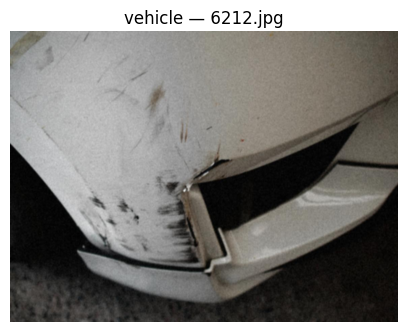

Generated labels:
{
  "object_type": "vehicle",
  "object_name": "car",
  "condition": "poor",
  "estimated_value_tier": "low",
  "location_context": "indoor/studio",
  "confidence_score": 0.9,
  "damage_type": "paint damage",
  "severity": "severe",
  "vehicle_part": "front bumper"
}

Parse success : True
Confidence    : 0.9


In [ ]:
# ============================================================
# CELL 21: Spot Check — Run model on a single random image
# Use for quick quality verification after batch runs.
# ============================================================

from PIL import Image as PILImage
import matplotlib.pyplot as plt
import json

# ── Pick a row ───────────────────────────────────────────────
# To test a specific image, replace with:
# test_row = ground_truth[ground_truth["image_path"].str.contains("some_filename")].iloc[0]
test_row = ground_truth.sample(1).iloc[0]
test_row.index = [i.lower() for i in test_row.index]

print(f"Image   : {test_row['image_id']}")
print(f"Type    : {test_row['object_type']}")
print(f"GT name : {test_row['object_name']}")
print()

# ── Show image ───────────────────────────────────────────────
try:
    img = PILImage.open(test_row["image_path"])
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{test_row['object_type']} — {test_row['image_id']}")
    plt.show()
except Exception as e:
    print(f"Could not display image: {e}")

# ── Run inference ────────────────────────────────────────────
try:
    result = generate_labels_from_image(
        image_path  = test_row["image_path"],
        object_type = test_row["object_type"],
        image_id    = test_row["image_id"],
    )
    print("Generated labels:")
    print(json.dumps(result["labels"], indent=2))
    print(f"\nParse success : {result['parse_success']}")
    print(f"Confidence    : {result['labels'].get('confidence_score', '?')}")
except Exception as e:
    print(f"Inference failed: {e}")

In [ ]:
# ============================================================
# CELL 22: [UTILITY] Wipe SYNTHETIC_LABELS — USE WITH CAUTION
# Only run this if you want to start the batch pipeline fresh.
# ============================================================

CONFIRM_WIPE = False  # ← Set to True to actually wipe

if CONFIRM_WIPE:
    conn   = get_sf_conn()
    cursor = conn.cursor()
    try:
        cursor.execute("TRUNCATE TABLE SYNTHETIC_LABELS")
        print("SYNTHETIC_LABELS cleared — ready for clean re-run")
    except Exception as e:
        print(f"Truncate failed: {e}")
    finally:
        cursor.close()
        conn.close()
else:
    print("CONFIRM_WIPE=False — table not modified. Set to True to wipe.")

CONFIRM_WIPE=False — table not modified. Set to True to wipe.
